# Image Augmentation Testing with Albumentations

This notebook helps you test different augmentation configurations and export them for use in the vision tokenization pipeline.

**Features:**
- Load and preview benchmark images
- Configure augmentation pipeline interactively
- Test augmentations on multiple images
- Export configuration as JSON for tokenization pipeline

In [1]:
# Cell 1: Setup and Imports
import albumentations as A
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Load example images from assets/original
ASSETS_DIR = Path("../../assets/original")
image_files = sorted(list(ASSETS_DIR.glob("*.png")) + list(ASSETS_DIR.glob("*.jpg")) + list(ASSETS_DIR.glob("*.jpeg")))
print(f"Found {len(image_files)} images")
for i, img_path in enumerate(image_files):
    print(f"  {i}: {img_path.name}")

/Users/rkre/miniconda3/envs/thesis/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/Users/rkre/miniconda3/envs/thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 14 images
  0: 3objects.png
  1: building.jpg
  2: checkerboard_pattern.png
  3: cute_dog.jpg
  4: graph_theory1.png
  5: line_chart.png
  6: logo1.png
  7: logo2.png
  8: math_draft1.png
  9: menu.jpeg
  10: mri_human_brain.png
  11: physics1.png
  12: physics2.png
  13: tcp_1.png


3objects.png: mode=RGB
building.jpg: mode=RGB
checkerboard_pattern.png: mode=RGB
cute_dog.jpg: mode=RGB
graph_theory1.png: mode=RGB
line_chart.png: mode=RGB
logo1.png: mode=RGB
logo2.png: mode=RGB
math_draft1.png: mode=RGB
menu.jpeg: mode=RGB
mri_human_brain.png: mode=RGB
physics1.png: mode=RGB
physics2.png: mode=RGB
tcp_1.png: mode=RGB


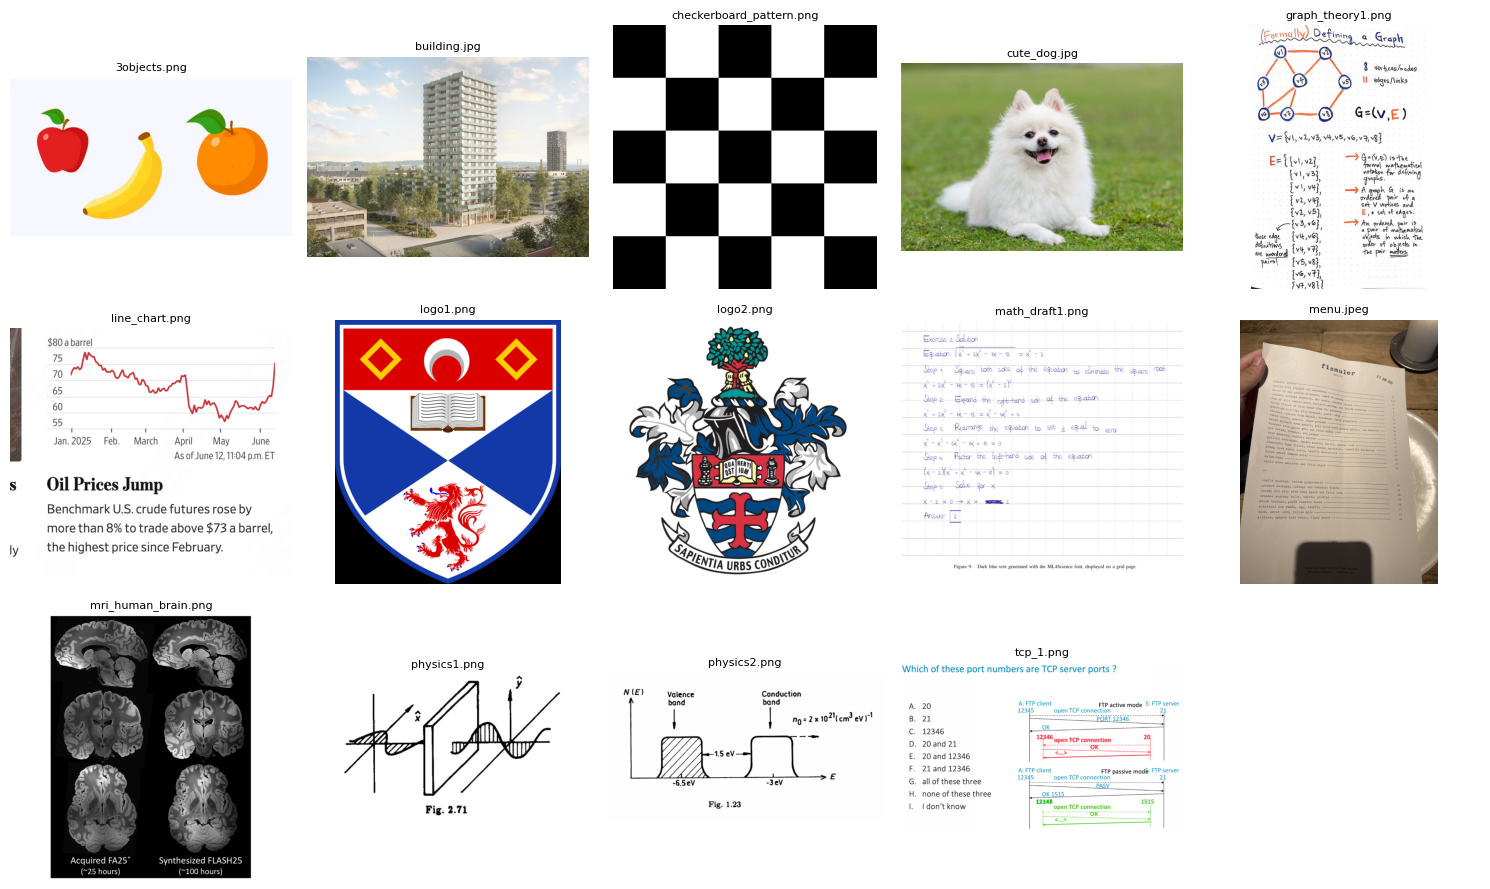

In [9]:
# Cell 2: Display Available Images
# Show thumbnails of all available images
num_images = len(image_files)
cols = 5
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten() if rows > 1 else [axes]

for idx, img_path in enumerate(image_files):
    img = Image.open(img_path).convert('RGB')
    print(f"{img_path.name}: mode={img.mode}")
    axes[idx].imshow(img)
    axes[idx].set_title(img_path.name, fontsize=8)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(num_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [29]:
# Cell 3: Configure Augmentation Pipeline

# === CHOOSE CONSTRUCTION METHOD ===
# Set to True for code-based (Pythonic), False for dict-based (matches JSON format)
USE_CODE_BASED = True

if USE_CODE_BASED:
    # === METHOD 1: Code-based construction (more Pythonic) ===
    # Easier to write with IDE autocomplete support
    
    pipeline = A.Compose([
        A.Affine(scale=(0.9, 1.1), translate_percent=0.05, p=0.4),
        A.Rotate(limit=25, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1, p=0.5),
        A.GaussianBlur(p=0.3),
        A.CoarseDropout(num_holes_range=(1, 4), p=0.3)
    ], p=1.0)  # p=1.0 is the global probability
    
    # Extract config for export (converts code to dict format)
    pipeline_dict = pipeline.to_dict()
    augmentation_config = pipeline_dict['transform']['transforms']
    global_probability = pipeline_dict['transform']['p']

else:
    # === METHOD 2: Dict-based construction (matches pipeline JSON format) ===
    # Easier to copy-paste from examples, matches export format exactly
    
    # User can modify this to test different augmentations
    augmentation_config = [
        {
            "__class_fullname__": "HorizontalFlip",
            "p": 0.5
        },
        {
            "__class_fullname__": "Rotate",
            "limit": 30,
            "p": 0.5
        },
        {
            "__class_fullname__": "ColorJitter",
            "brightness": 0.2,
            "contrast": 0.2,
            "saturation": 0.1,
            "hue": 0.1,
            "p": 0.5
        }
    ]
    
    # Global probability
    global_probability = 1.0
    
    # Build albumentations pipeline from dict
    pipeline_dict = {
        "transform": {
            "__class_fullname__": "Compose",
            "p": float(global_probability),
            "transforms": augmentation_config
        }
    }
    
    pipeline = A.from_dict(pipeline_dict)

# Print pipeline info
print("✓ Pipeline created successfully!")
print(f"  Construction method: {'Code-based (A.Compose)' if USE_CODE_BASED else 'Dict-based (JSON format)'}")
print(f"  Global probability: {global_probability}")
print(f"  Number of augmentations: {len(augmentation_config)}")
print("\nPipeline details:")
for i, aug in enumerate(augmentation_config, 1):
    name = aug['__class_fullname__']
    prob = aug.get('p', 1.0)
    params = {k: v for k, v in aug.items() if k not in ['__class_fullname__', 'p']}
    if params:
        print(f"  {i}. {name} (p={prob}, {params})")
    else:
        print(f"  {i}. {name} (p={prob})")

✓ Pipeline created successfully!
  Construction method: Code-based (A.Compose)
  Global probability: 1.0
  Number of augmentations: 5

Pipeline details:
  1. Affine (p=0.4, {'balanced_scale': False, 'border_mode': 0, 'fill': 0.0, 'fill_mask': 0.0, 'fit_output': False, 'interpolation': 1, 'keep_ratio': False, 'mask_interpolation': 0, 'rotate': (0.0, 0.0), 'rotate_method': 'largest_box', 'scale': {'x': (0.9, 1.1), 'y': (0.9, 1.1)}, 'shear': {'x': (0.0, 0.0), 'y': (0.0, 0.0)}, 'translate_percent': {'x': (0.05, 0.05), 'y': (0.05, 0.05)}, 'translate_px': None})
  2. Rotate (p=0.5, {'border_mode': 0, 'crop_border': False, 'fill': 0.0, 'fill_mask': 0.0, 'interpolation': 1, 'limit': (-25.0, 25.0), 'mask_interpolation': 0, 'rotate_method': 'largest_box'})
  3. ColorJitter (p=0.5, {'brightness': (0.8, 1.2), 'contrast': (0.8, 1.2), 'hue': (-0.1, 0.1), 'saturation': (0.9, 1.1)})
  4. GaussianBlur (p=0.3, {'blur_limit': (0, 0), 'sigma_limit': (0.5, 3.0)})
  5. CoarseDropout (p=0.3, {'fill': 0.0, 'f

Np-Img_shape: (356, 640, 3)


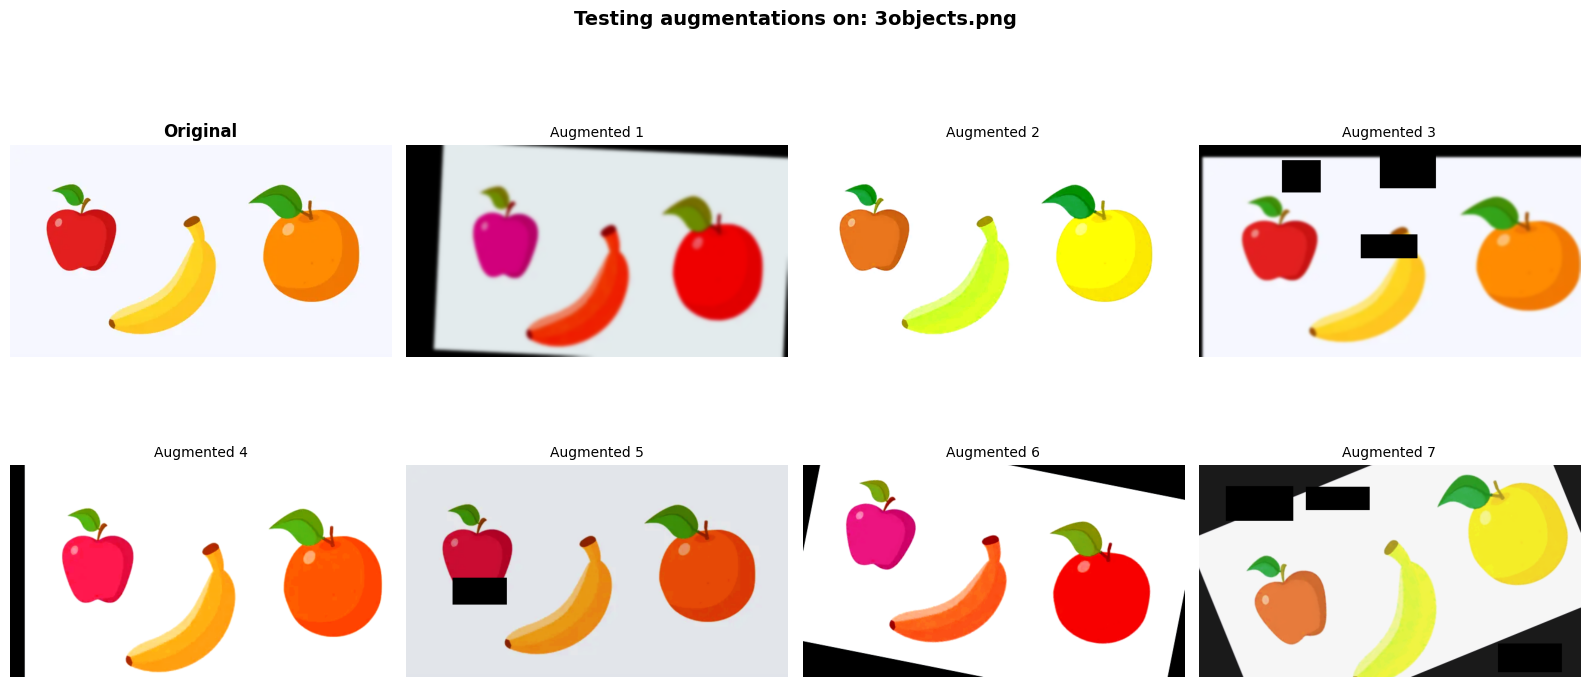

In [26]:
# Cell 4: Test on Selected Image
# Select an image to test
test_image_idx = 0  # Change this to test different images
test_image_path = image_files[test_image_idx]

# Load image
original_img = Image.open(test_image_path).convert('RGB')
original_np = np.array(original_img)
print(f"Np-Img_shape: {original_np.shape}")

# Apply augmentations multiple times to see variety
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Show original
axes[0].imshow(original_img)
axes[0].set_title("Original", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Show augmented versions
for i in range(1, 8):
    augmented = pipeline(image=original_np)
    augmented_img = Image.fromarray(augmented['image'])
    axes[i].imshow(augmented_img)
    axes[i].set_title(f"Augmented {i}", fontsize=10)
    axes[i].axis('off')

plt.suptitle(f"Testing augmentations on: {test_image_path.name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

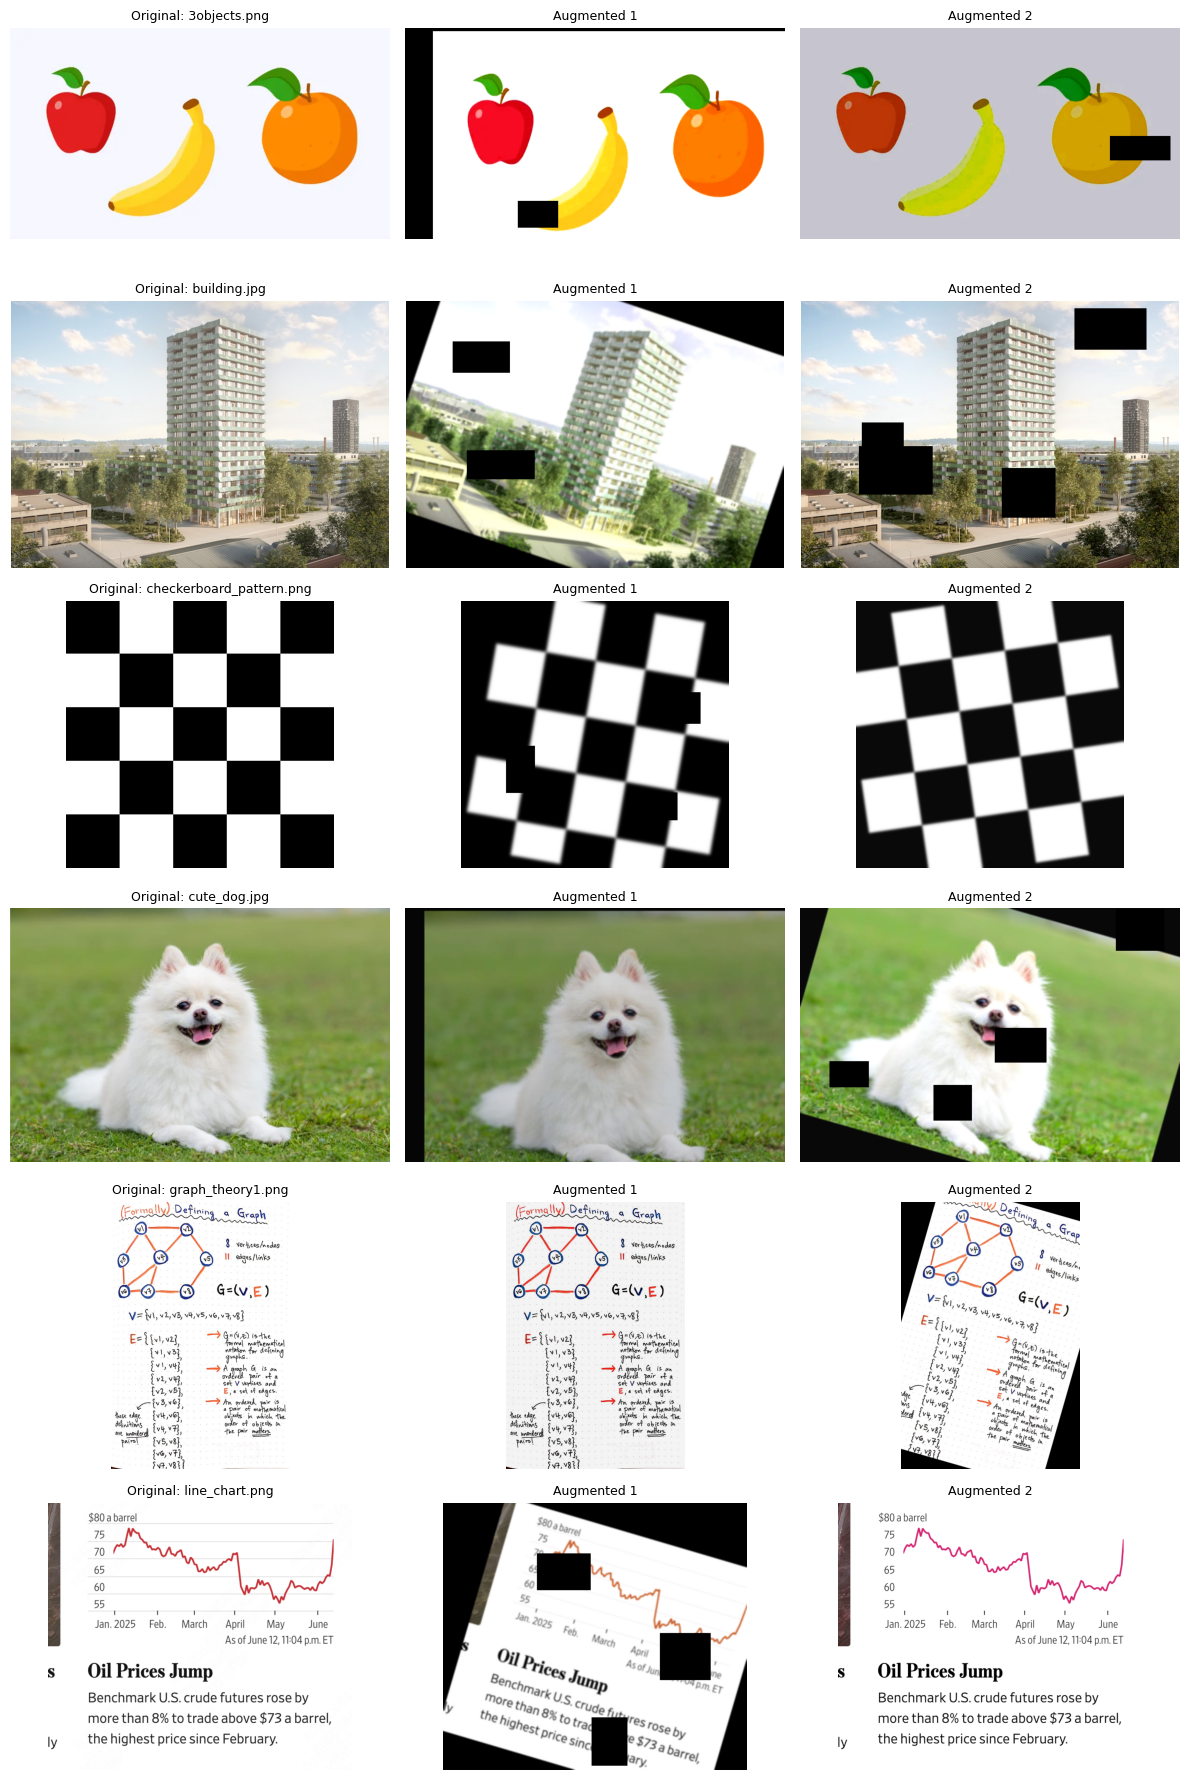

In [28]:
# Cell 5: Test on Multiple Images
# Apply augmentation to multiple images to see variety
num_test_images = min(6, len(image_files))

fig, axes = plt.subplots(num_test_images, 3, figsize=(12, num_test_images * 3))
if num_test_images == 1:
    axes = axes.reshape(1, -1)

for i in range(num_test_images):
    img_path = image_files[i]
    original_img = Image.open(img_path).convert('RGB')
    original_np = np.array(original_img)

    # Original
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Original: {img_path.name}", fontsize=9)
    axes[i, 0].axis('off')

    # Two augmented versions
    for j in range(2):
        augmented = pipeline(image=original_np)
        augmented_img = Image.fromarray(augmented['image'])
        axes[i, j+1].imshow(augmented_img)
        axes[i, j+1].set_title(f"Augmented {j+1}", fontsize=9)
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.show()

In [30]:
# Cell 6: Export Configuration to JSON
# Export the augmentation config in the format needed for vision tokenization pipeline

export_config = {
    "random_augment": {
        "probability": global_probability,
        "transforms": augmentation_config
    }
}

# Pretty print the config
print("=" * 80)
print("Configuration for vision_tokenization/configs/*.json")
print("=" * 80)
print("Add this to your config file under 'transform_params':")
print()
print(json.dumps(export_config, indent=2))
print()
print("=" * 80)
print("Full example config:")
print("=" * 80)

full_config_example = {
    "tokenizer_path": "/path/to/tokenizer",
    "output_dir": "./output",
    "dataset_name": "your/dataset",
    "mode": "image_only",
    "image_field": "image",
    "image_transforms": "random_augment",
    "transform_params": export_config
}

print(json.dumps(full_config_example, indent=2))

# Save to file
output_path = Path("augmentation_config.json")
with open(output_path, 'w') as f:
    json.dump(export_config, f, indent=2)

print()
print(f"✓ Configuration saved to: {output_path.absolute()}")

Configuration for vision_tokenization/configs/*.json
Add this to your config file under 'transform_params':

{
  "random_augment": {
    "probability": 1.0,
    "transforms": [
      {
        "__class_fullname__": "Affine",
        "p": 0.4,
        "balanced_scale": false,
        "border_mode": 0,
        "fill": 0.0,
        "fill_mask": 0.0,
        "fit_output": false,
        "interpolation": 1,
        "keep_ratio": false,
        "mask_interpolation": 0,
        "rotate": [
          0.0,
          0.0
        ],
        "rotate_method": "largest_box",
        "scale": {
          "x": [
            0.9,
            1.1
          ],
          "y": [
            0.9,
            1.1
          ]
        },
        "shear": {
          "x": [
            0.0,
            0.0
          ],
          "y": [
            0.0,
            0.0
          ]
        },
        "translate_percent": {
          "x": [
            0.05,
            0.05
          ],
          "y": [
         

In [18]:
# Cell 7: Documentation - Available Transforms
# Display common albumentations transforms for reference
print("Common Albumentations Transforms:")
print("=" * 80)
print()

transforms_reference = {
    "Geometric": [
        {"name": "HorizontalFlip", "params": {"p": 0.5}},
        {"name": "VerticalFlip", "params": {"p": 0.5}},
        {"name": "Rotate", "params": {"limit": 45, "p": 0.5}},
        {"name": "ShiftScaleRotate", "params": {"shift_limit": 0.0625, "scale_limit": 0.1, "rotate_limit": 45, "p": 0.5}},
        {"name": "Affine", "params": {"scale": [0.9, 1.1], "translate_percent": {"x": [-0.1, 0.1], "y": [-0.1, 0.1]}, "p": 0.5}}
    ],
    "Color": [
        {"name": "ColorJitter", "params": {"brightness": 0.2, "contrast": 0.2, "saturation": 0.2, "hue": 0.1, "p": 0.5}},
        {"name": "HueSaturationValue", "params": {"hue_shift_limit": 20, "sat_shift_limit": 30, "val_shift_limit": 20, "p": 0.5}},
        {"name": "RGBShift", "params": {"r_shift_limit": 20, "g_shift_limit": 20, "b_shift_limit": 20, "p": 0.5}},
        {"name": "RandomBrightnessContrast", "params": {"brightness_limit": 0.2, "contrast_limit": 0.2, "p": 0.5}},
        {"name": "RandomGamma", "params": {"gamma_limit": [80, 120], "p": 0.5}}
    ],
    "Blur/Noise": [
        {"name": "GaussianBlur", "params": {"blur_limit": [3, 7], "p": 0.5}},
        {"name": "MotionBlur", "params": {"blur_limit": 7, "p": 0.5}},
        {"name": "MedianBlur", "params": {"blur_limit": 5, "p": 0.5}},
        {"name": "GaussNoise", "params": {"var_limit": [10.0, 50.0], "p": 0.5}}
    ],
    "Dropout": [
        {"name": "CoarseDropout", "params": {"max_holes": 8, "max_height": 8, "max_width": 8, "p": 0.5}},
        {"name": "GridDropout", "params": {"ratio": 0.5, "p": 0.5}}
    ]
}

for category, transforms in transforms_reference.items():
    print(f"\n{category}:")
    print("-" * 80)
    for t in transforms:
        config = dict(__class_fullname__=t['name'], **t['params'])
        print(f"  {t['name']}")
        print(f"    {json.dumps(config, indent=4)}")
    print()

print("\nFor full documentation, visit: https://albumentations.ai/docs/")

Common Albumentations Transforms:


Geometric:
--------------------------------------------------------------------------------
  HorizontalFlip
    {
    "__class_fullname__": "HorizontalFlip",
    "p": 0.5
}
  VerticalFlip
    {
    "__class_fullname__": "VerticalFlip",
    "p": 0.5
}
  Rotate
    {
    "__class_fullname__": "Rotate",
    "limit": 45,
    "p": 0.5
}
  ShiftScaleRotate
    {
    "__class_fullname__": "ShiftScaleRotate",
    "shift_limit": 0.0625,
    "scale_limit": 0.1,
    "rotate_limit": 45,
    "p": 0.5
}
  Affine
    {
    "__class_fullname__": "Affine",
    "scale": [
        0.9,
        1.1
    ],
    "translate_percent": {
        "x": [
            -0.1,
            0.1
        ],
        "y": [
            -0.1,
            0.1
        ]
    },
    "p": 0.5
}


Color:
--------------------------------------------------------------------------------
  ColorJitter
    {
    "__class_fullname__": "ColorJitter",
    "brightness": 0.2,
    "contrast": 0.2,
    "sa